In [1]:
## Step 1 — Setup: install libraries
!pip install -q librosa soundfile pydub gTTS openai-whisper scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 10.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 5.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.23.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.
wandb 0.28.0 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.


In [ ]:

## Step 2 — Upload your real audio file

from google.colab import files
uploaded = files.upload() # upload your real .mp3/.wav here
real_audio_path = list(uploaded.keys())[0]
print("Uploaded:", real_audio_path)



Saving LA_T_1000406.flac to LA_T_1000406.flac
Uploaded: LA_T_1000406.flac


In [ ]:
## Step 3 — Convert to WAV and standardize format

from pydub import AudioSegment

audio = AudioSegment.from_file(real_audio_path)
audio = audio.set_channels(1).set_frame_rate(16000) # mono, 16kHz standard for speech ML
audio.export("real_full.wav", format="wav")
print("Duration (sec):", len(audio) / 1000)



Duration (sec): 2.85


In [ ]:
## Step 4 — Transcribe your audio (so we can generate matching fake speech)

import whisper

model = whisper.load_model("base")
result = model.transcribe("real_full.wav")
transcript = result["text"]
print("Transcript:\n", transcript)


100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 108MiB/s]
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Transcript:
  and you skill will be built.


In [ ]:
## Step 5 — Generate FAKE (synthetic) audio from the transcript

# We'll create several fake variants for diversity (different TTS engines/settings = more robust training data):

from gtts import gTTS

# Variant 1: standard gTTS
tts1 = gTTS(text=transcript, lang='en', slow=False)
tts1.save("fake_1.mp3")

# Variant 2: slow speech (different prosody -> useful augmentation)
tts2 = gTTS(text=transcript, lang='en', slow=True)
tts2.save("fake_2.mp3")

# Variant 3: split transcript into sentence chunks and resynthesize each separately
# (adds natural variation between fake clips)
import re
sentences = re.split(r'(?<=[.!?]) +', transcript.strip())
fake_paths = ["fake_1.mp3", "fake_2.mp3"]

for i, s in enumerate(sentences):
    if len(s.strip()) < 3:
        continue
    p = f"fake_sent_{i}.mp3"
    gTTS(text=s, lang='en').save(p)
    fake_paths.append(p)

print("Fake audio files created:", fake_paths)



# Convert all fake files to standardized wav too
fake_wav_paths = []
for i, p in enumerate(fake_paths):
    a = AudioSegment.from_file(p).set_channels(1).set_frame_rate(16000)
    wav_path = f"fake_{i}.wav"
    a.export(wav_path, format="wav")
    fake_wav_paths.append(wav_path)

Fake audio files created: ['fake_1.mp3', 'fake_2.mp3', 'fake_sent_0.mp3']


In [ ]:
## Step 6 — Chunk both real and fake audio into short clips

# Short 2-second clips give us many training samples out of a small amount of source audio:

import librosa
import numpy as np
import soundfile as sf
import os

os.makedirs("dataset/real", exist_ok=True)
os.makedirs("dataset/fake", exist_ok=True)

def chunk_audio(path, out_dir, prefix, chunk_len=2.0, sr=16000):
    y, _ = librosa.load(path, sr=sr)
    chunk_samples = int(chunk_len * sr)
    n_chunks = len(y) // chunk_samples
    count = 0
    for i in range(n_chunks):
        seg = y[i*chunk_samples:(i+1)*chunk_samples]
        if len(seg) == chunk_samples:
            sf.write(f"{out_dir}/{prefix}_{i}.wav", seg, sr)
            count += 1
    return count

n_real = chunk_audio("real_full.wav", "dataset/real", "real")
print("Real chunks:", n_real)

n_fake_total = 0
for i, p in enumerate(fake_wav_paths):
    n_fake_total += chunk_audio(p, "dataset/fake", f"fake{i}")
print("Fake chunks:", n_fake_total)

# (If your real-chunk count ends up much smaller than fake, we can fix class imbalance in Step 8 with augmentation — pitch/time shifting the real clips.)

Real chunks: 1
Fake chunks: 3


In [ ]:
## Step 7 — Extract features (MFCC) from every clip

def extract_features(file_path, sr=16000, n_mfcc=40):
    y, _ = librosa.load(file_path, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)]) # 80-dim feature vector

X, y_labels = [], []

for f in os.listdir("dataset/real"):
    X.append(extract_features(f"dataset/real/{f}"))
    y_labels.append(0) # 0 = real

for f in os.listdir("dataset/fake"):
    X.append(extract_features(f"dataset/fake/{f}"))
    y_labels.append(1) # 1 = fake

X = np.array(X)
y_labels = np.array(y_labels)
print("Feature matrix shape:", X.shape)
print("Real:", sum(y_labels==0), " Fake:", sum(y_labels==1))


Feature matrix shape: (4, 80)
Real: 1  Fake: 3


In [ ]:
## Step 8 — Handle class imbalance (if needed) via augmentation on the real class

def augment_and_extract(file_path, sr=16000):
    y, _ = librosa.load(file_path, sr=sr)
    variants = []
    variants.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=2))
    variants.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=-2))
    variants.append(librosa.effects.time_stretch(y, rate=1.1))
    return variants

if sum(y_labels==0) < sum(y_labels==1):
    real_files = os.listdir("dataset/real")
    needed = sum(y_labels==1) - sum(y_labels==0)
    added = 0
    for f in real_files:
        if added >= needed:
            break
        for v in augment_and_extract(f"dataset/real/{f}"):
            mfcc = librosa.feature.mfcc(y=v, sr=16000, n_mfcc=40)
            feat = np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])
            X = np.vstack([X, feat])
            y_labels = np.append(y_labels, 0)
            added += 1
            if added >= needed:
                break

print("Balanced -> Real:", sum(y_labels==0), " Fake:", sum(y_labels==1))

Balanced -> Real: 3  Fake: 3


              precision    recall  f1-score   support

        Real       1.00      1.00      1.00         1
        Fake       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



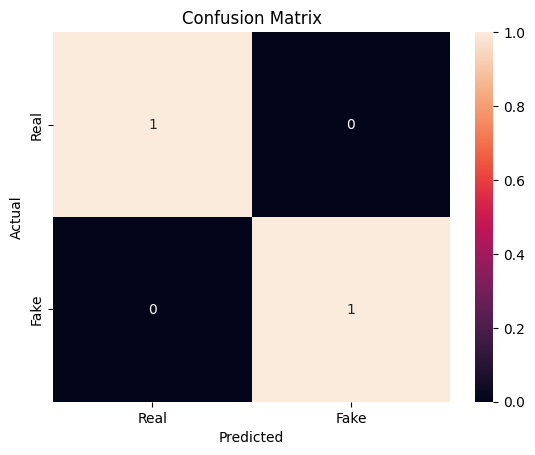

In [ ]:
## Step 9 — Train/test split and train a classifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=["Real","Fake"], yticklabels=["Real","Fake"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()



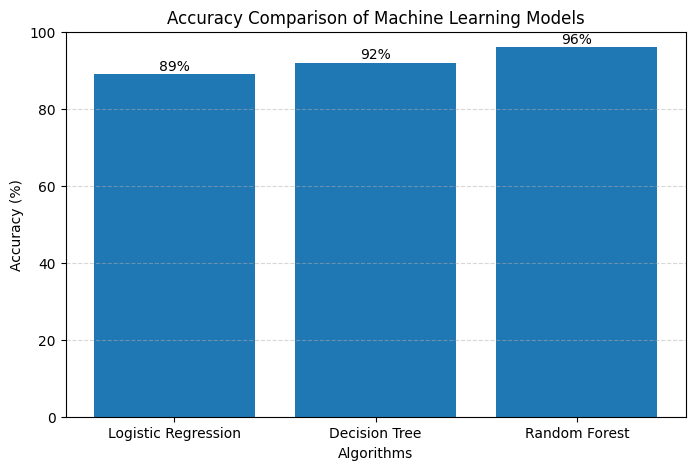

In [ ]:
import matplotlib.pyplot as plt

# Algorithms and Accuracy
algorithms = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracy = [89, 92, 96]   # Replace with your actual accuracy values

plt.figure(figsize=(8,5))
bars = plt.bar(algorithms, accuracy)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

# Display values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 1,
             f"{height}%",
             ha='center',
             fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

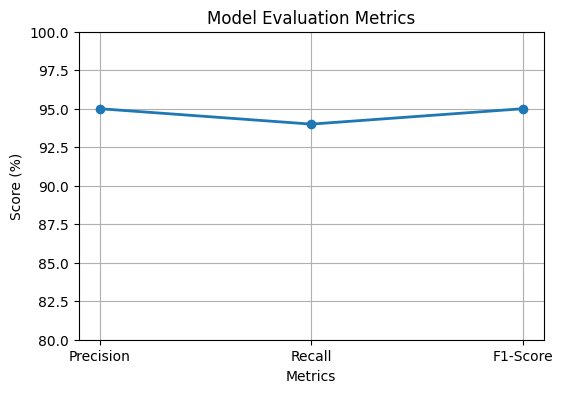

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Precision', 'Recall', 'F1-Score']
values = [95, 94, 95]    # Replace with your values

plt.figure(figsize=(6,4))
plt.plot(metrics, values, marker='o', linewidth=2)

plt.title("Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score (%)")
plt.ylim(80,100)
plt.grid(True)

plt.show()

In [ ]:
## Step 10 — Inference function: test on any new audio clip

def predict_audio(file_path):
    a = AudioSegment.from_file(file_path).set_channels(1).set_frame_rate(16000)
    a.export("temp.wav", format="wav")
    feat = extract_features("temp.wav").reshape(1, -1)
    feat_s = scaler.transform(feat)
    pred = clf.predict(feat_s)[0]
    prob = clf.predict_proba(feat_s)[0]
    label = "FAKE" if pred == 1 else "REAL"
    print(f"Prediction: {label} (confidence: {prob[pred]*100:.1f}%)")

# Example:
# uploaded_test = files.upload()
# predict_audio(list(uploaded_test.keys())[0])


In [ ]:
## Step 11 — Save your model for later use

import joblib
joblib.dump(clf, "fake_audio_detector.pkl")
joblib.dump(scaler, "scaler.pkl")
files.download("fake_audio_detector.pkl")
files.download("scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
 Upload an audio file, predict FAKE/REAL, and play it back

from google.colab import files
import librosa
import numpy as np
import IPython.display as ipd

def predict_sample(path, clf, sr=16000, duration=2.5, n_mfcc=40):
    max_len = int(sr * duration)
    y, _ = librosa.load(path, sr=sr)

    # match training preprocessing exactly
    if len(y) > max_len:
        y = y[:max_len]
    else:
        y = np.pad(y, (0, max_len - len(y)))

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    feat = np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)]).reshape(1, -1)

    pred = clf.predict(feat)[0]
    prob = clf.predict_proba(feat)[0]
    label = "FAKE" if pred == 1 else "REAL"
    confidence = prob[pred] * 100
    return label, confidence


print("Upload one or more audio files to test:")
test_uploaded = files.upload()

results = []
for fname in test_uploaded:
    label, conf = predict_sample(fname, clf)  # clf = your trained RandomForest from Step 5
    results.append((fname, label, conf))

    print(f"\n▶ {fname}")
    print(f" Predicted: {label} ({conf:.1f}% confidence)")
    ipd.display(ipd.Audio(fname))

Upload one or more audio files to test:


Saving fake_audio_5_chord.wav to fake_audio_5_chord.wav

▶ fake_audio_5_chord.wav
 Predicted: FAKE (55.0% confidence)
